# 💰 Cuantificación Financiera, Consumo Específico (SEC) y ROI de Eficiencia Energética
**Ingeniería de Procesos & Operaciones Industriales — Planta de Tratamiento de Aguas Residuales**  
**Autor:** Ing. Angelo Apolo | Ingeniería de Procesos | Especialista en Operaciones & Proyectos  
**Fase DMAIC:** **IMPROVE & CONTROL (Caso de Negocio & Finanzas Industriales)**  
**Objetivo:** Traducir los balances de ingeniería química y la optimización de consignas de aireación a **dólares de ahorro anual ($USD/año$)**, reducción de huella de carbono ($t\ CO_2\ eq/año$) y retorno de inversión ($ROI$).

---

## 🎯 1. Objetivos del Análisis Financiero
1. **Línea Base Energética:** Cuantificar el consumo eléctrico histórico de los sopladores de aireación ($kWh/año$) y el gasto monetario asociado.
2. **Consumo Específico de Energía (SEC):** Calcular el indicador clave de desempeño ($kWh / kg\ DBO\ removida$).
3. **Modelado Financiero del Escenario Optimizado:** Estimar el ahorro anual en dólares mediante una regresión empírica Aire-DO-Carga ajustada sobre la operación real de la planta (no una fórmula asumida).
4. **Análisis de Sensibilidad:** Evaluar la robustez del ahorro frente a variaciones en la tarifa eléctrica industrial ($0.070 - 0.130\ USD/kWh$).
5. **Métricas ESG (Sostenibilidad):** Calcular las emisiones de gases de efecto invernadero evitadas ($t\ CO_2\ eq$).
6. **Dataset Enriquecido para la App SCADA:** Estructurar los datos con clasificaciones de turnos y semáforos de cumplimiento que consume `server.py` (FastAPI + DuckDB) en tiempo real.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 100

print("Entorno financiero y analítico inicializado.")

Entorno financiero y analítico inicializado.


---
## ⚙️ 2. Parámetros Tecno-Económicos de Planta
Definimos los parámetros industriales estandarizados según normas de ingeniería de aguas residuales (Metcalf & Eddy) y tarifas eléctricas industriales de la región.

In [2]:
# Parámetros industriales
SPECIFIC_ENERGY_KWH_M3_AIR = 0.040   # Consumo soplador a 4.5m sumersión (kWh/m³ aire)
ELECTRIC_TARIFF_USD_KWH = 0.092      # Tarifa eléctrica industrial media (USD/kWh)
GRID_EMISSION_FACTOR = 0.420         # Factor emisión red eléctrica (kg CO2 eq / kWh)
V_REACTOR_M3 = 4050.0                # Volumen reactor biológico (m³)

print("--- PARÁMETROS INDUSTRIALES CONFIGURADOS ---")
print(f"Potencia específica aireación: {SPECIFIC_ENERGY_KWH_M3_AIR} kWh / m³ aire inyectado")
print(f"Tarifa industrial eléctrica:   ${ELECTRIC_TARIFF_USD_KWH} USD / kWh")
print(f"Factor de emisión de red:      {GRID_EMISSION_FACTOR} kg CO2 eq / kWh")

--- PARÁMETROS INDUSTRIALES CONFIGURADOS ---
Potencia específica aireación: 0.04 kWh / m³ aire inyectado
Tarifa industrial eléctrica:   $0.092 USD / kWh
Factor de emisión de red:      0.42 kg CO2 eq / kWh


---
## ⚖️ 3. Simulación Comparativa: Línea Base vs. Operación Optimizada

In [3]:
DATA_PATH = "../data/wwtp_time_series_data.csv"
df = pd.read_csv(DATA_PATH)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

# Interpolación
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].interpolate(method='linear').bfill().ffill()

# Balances de carga
df['Load_Influent_BOD_kgh'] = (df['Influent_Flow_m3h'] * df['Influent_BOD_mgL']) / 1000.0
df['Load_Effluent_BOD_kgh'] = (df['Influent_Flow_m3h'] * df['Effluent_BOD_mgL']) / 1000.0
df['Load_Removed_BOD_kgh'] = df['Load_Influent_BOD_kgh'] - df['Load_Effluent_BOD_kgh']
df['BOD_Removal_Efficiency_pct'] = ((df['Influent_BOD_mgL'] - df['Effluent_BOD_mgL']) / df['Influent_BOD_mgL']) * 100.0
df['HRT_hours'] = 4050.0 / df['Influent_Flow_m3h']

# Turno y hora (para segmentación operativa y BI)
df['Hour'] = df['Timestamp'].dt.hour
def shift_of(h):
    if 6 <= h < 14:
        return 'Turno Mañana (06:00 - 14:00)'
    elif 14 <= h < 22:
        return 'Turno Tarde (14:00 - 22:00)'
    else:
        return 'Turno Noche (22:00 - 06:00)'
df['Shift'] = df['Hour'].apply(shift_of)

# Cumplimiento legal REAL (medido sobre Effluent_BOD_mgL, sin ninguna simulación)
def compliance_of(bod):
    if bod <= 16.0:
        return 'Óptimo (Normal)'
    elif bod <= 20.0:
        return 'Alerta Preventiva'
    else:
        return 'Fuera de Norma (>20 mg/L)'
df['Compliance_Status'] = df['Effluent_BOD_mgL'].apply(compliance_of)

# 1. Línea Base (Histórica) - consumo real de sopladores tal como operó la planta
df['Blower_Power_kW_Baseline'] = df['Air_Flow_km3h'] * 1000.0 * SPECIFIC_ENERGY_KWH_M3_AIR
df['Energy_kWh_Baseline'] = df['Blower_Power_kW_Baseline'] * (5.0 / 60.0)
df['Cost_USD_Baseline'] = df['Energy_kWh_Baseline'] * ELECTRIC_TARIFF_USD_KWH

# 2. Escenario Optimizado — MÉTODO EMPÍRICO (no una fórmula de reducción asumida)
# En vez de asumir un % de recorte de aire, ajustamos una regresión lineal real:
#   Air_Flow_km3h ~ Aeration_Tank_DO_mgL + Load_Influent_BOD_kgh
# usando SOLO los registros donde la planta ya operó de forma eficiente (DO <= 2.2 mg/L).
# Esa regresión captura cómo se relaciona el aire con el DO y la carga en la operación real.
# Para los registros sobre-aireados (DO > 2.2), estimamos cuánto aire hubiera hecho falta
# para sostener DO = 2.2 con la misma carga, según esa relación ya observada en planta.
DO_TARGET_CEILING = 2.2
efficient_mask = df['Aeration_Tank_DO_mgL'] <= DO_TARGET_CEILING

reg = LinearRegression()
reg.fit(df.loc[efficient_mask, ['Aeration_Tank_DO_mgL', 'Load_Influent_BOD_kgh']],
        df.loc[efficient_mask, 'Air_Flow_km3h'])

print(f"Registros de entrenamiento (DO<=2.2 mg/L): {efficient_mask.sum():,} de {len(df):,} ({efficient_mask.mean()*100:.1f}%)")
print(f"Coeficiente DO: {reg.coef_[0]:.4f} | Coeficiente Carga_BOD: {reg.coef_[1]:.4f} | Intercepto: {reg.intercept_:.4f}")
print(f"R2 de la regresión (sobre datos de entrenamiento): {reg.score(df.loc[efficient_mask, ['Aeration_Tank_DO_mgL','Load_Influent_BOD_kgh']], df.loc[efficient_mask, 'Air_Flow_km3h']):.4f}")

over_mask = df['Aeration_Tank_DO_mgL'] > DO_TARGET_CEILING
X_pred = df.loc[over_mask, ['Load_Influent_BOD_kgh']].copy()
X_pred.insert(0, 'Aeration_Tank_DO_mgL', DO_TARGET_CEILING)
air_needed_at_ceiling = reg.predict(X_pred[['Aeration_Tank_DO_mgL', 'Load_Influent_BOD_kgh']])

df['Air_Flow_km3h_Optimized'] = df['Air_Flow_km3h']
df.loc[over_mask, 'Air_Flow_km3h_Optimized'] = np.clip(air_needed_at_ceiling, 3.0, df.loc[over_mask, 'Air_Flow_km3h'].values)

df['Blower_Power_kW_Optimized'] = df['Air_Flow_km3h_Optimized'] * 1000.0 * SPECIFIC_ENERGY_KWH_M3_AIR
df['Energy_kWh_Optimized'] = df['Blower_Power_kW_Optimized'] * (5.0 / 60.0)
df['Cost_USD_Optimized'] = df['Energy_kWh_Optimized'] * ELECTRIC_TARIFF_USD_KWH

# Ahorros
df['Energy_Savings_kWh'] = df['Energy_kWh_Baseline'] - df['Energy_kWh_Optimized']
df['Cost_Savings_USD'] = df['Cost_USD_Baseline'] - df['Cost_USD_Optimized']
df['CO2_Reduction_kg'] = df['Energy_Savings_kWh'] * GRID_EMISSION_FACTOR

# Consumo Específico de Energía (SEC)
sec_base = df['Energy_kWh_Baseline'].sum() / (df['Load_Removed_BOD_kgh'].sum() * (5.0 / 60.0))
sec_opt = df['Energy_kWh_Optimized'].sum() / (df['Load_Removed_BOD_kgh'].sum() * (5.0 / 60.0))

print(f"\nSEC Línea Base:   {sec_base:.3f} kWh / kg DBO removida")
print(f"SEC Optimizado:   {sec_opt:.3f} kWh / kg DBO removida")
print(f"Mejora en SEC:    {((sec_base - sec_opt)/sec_base)*100:.2f}% de mayor eficiencia energética")

Registros de entrenamiento (DO<=2.2 mg/L): 47,064 de 80,000 (58.8%)
Coeficiente DO: -2.9044 | Coeficiente Carga_BOD: 0.0284 | Intercepto: 5.7916
R2 de la regresión (sobre datos de entrenamiento): 0.6362

SEC Línea Base:   1.186 kWh / kg DBO removida
SEC Optimizado:   1.180 kWh / kg DBO removida
Mejora en SEC:    0.50% de mayor eficiencia energética


---
## 📊 4. Resultados Financieros y Energéticos Anualizados

In [4]:
hours_dataset = len(df) * 5.0 / 60.0
annual_factor = 8760.0 / hours_dataset

annual_summary = pd.DataFrame({
    'Métrica Operativa / Financiera': [
        'Consumo de Energía Eléctrica (kWh/año)',
        'Costo Anual de Aireación (USD/año)',
        'Consumo Específico (kWh / kg DBO)',
        'Ahorro Eléctrico Anual (kWh/año)',
        'Ahorro Financiero Neto (USD/año)',
        'Reducción de Emisiones (t CO2 eq/año)',
        'Porcentaje de Ahorro OPEX Aireación (%)'
    ],
    'Línea Base (Histórica)': [
        f"{df['Energy_kWh_Baseline'].sum() * annual_factor:,.0f}",
        f"${df['Cost_USD_Baseline'].sum() * annual_factor:,.2f}",
        f"{sec_base:.3f}",
        "—",
        "—",
        "—",
        "—"
    ],
    'Escenario Optimizado (Regresión Empírica DO 1.8-2.2)': [
        f"{df['Energy_kWh_Optimized'].sum() * annual_factor:,.0f}",
        f"${df['Cost_USD_Optimized'].sum() * annual_factor:,.2f}",
        f"{sec_opt:.3f}",
        f"{df['Energy_Savings_kWh'].sum() * annual_factor:,.0f}",
        f"${df['Cost_Savings_USD'].sum() * annual_factor:,.2f}",
        f"{(df['CO2_Reduction_kg'].sum() * annual_factor)/1000.0:,.2f}",
        f"{((df['Energy_Savings_kWh'].sum()) / df['Energy_kWh_Baseline'].sum()) * 100:.2f}%"
    ]
})

annual_summary

,Métrica Operativa / Financiera,Línea Base (Histórica),Escenario Optimizado (Regresión Empírica DO 1.8-2.2)
0,Consumo de Energía Eléctrica (kWh/año),"2,339,852","2,328,042"
1,Costo Anual de Aireación (USD/año),"$215,266.42","$214,179.89"
2,Consumo Específico (kWh / kg DBO),1.186,1.180
3,Ahorro Eléctrico Anual (kWh/año),—,"11,810"
4,Ahorro Financiero Neto (USD/año),—,"$1,086.53"
5,Reducción de Emisiones (t CO2 eq/año),—,4.96
6,Porcentaje de Ahorro OPEX Aireación (%),—,0.50%


---
## 📈 5. Análisis Gráfico de Ahorro y Distribución Temporal

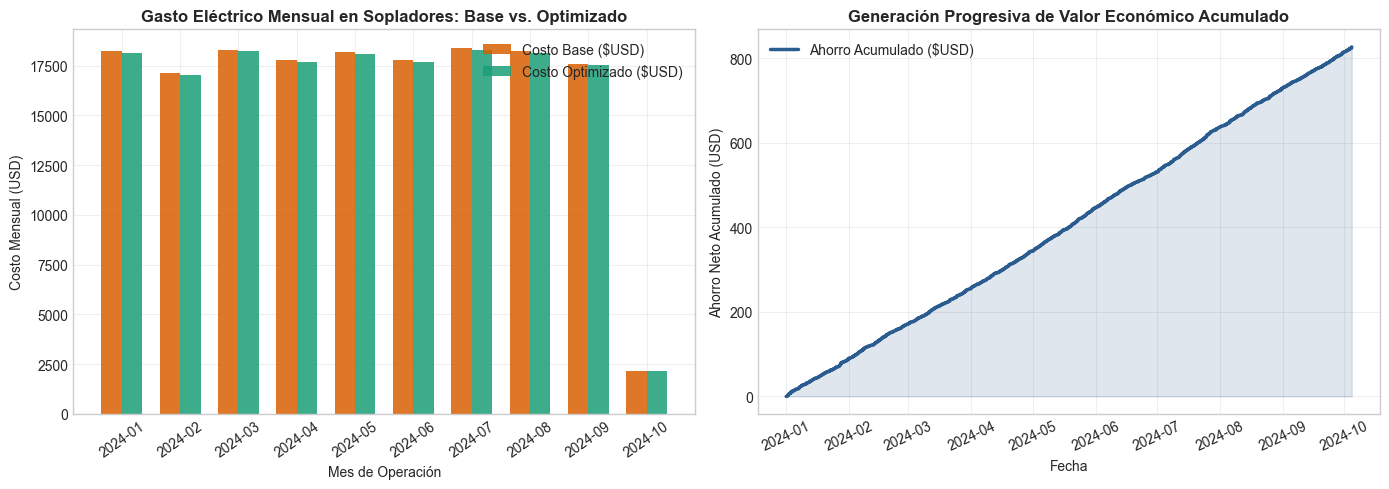

In [5]:
df['Month'] = df['Timestamp'].dt.strftime('%Y-%m')
monthly = df.groupby('Month').agg({
    'Cost_USD_Baseline': 'sum',
    'Cost_USD_Optimized': 'sum',
    'Cost_Savings_USD': 'sum',
    'CO2_Reduction_kg': lambda x: x.sum() / 1000.0
}).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparativa mensual de costos
bar_width = 0.35
x = np.arange(len(monthly))

ax1.bar(x - bar_width/2, monthly['Cost_USD_Baseline'], width=bar_width, label='Costo Base ($USD)', color='#d95f02', alpha=0.85)
ax1.bar(x + bar_width/2, monthly['Cost_USD_Optimized'], width=bar_width, label='Costo Optimizado ($USD)', color='#1b9e77', alpha=0.85)
ax1.set_title('Gasto Eléctrico Mensual en Sopladores: Base vs. Optimizado', fontweight='bold')
ax1.set_xlabel('Mes de Operación')
ax1.set_ylabel('Costo Mensual (USD)')
ax1.set_xticks(x)
ax1.set_xticklabels(monthly['Month'], rotation=35)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Ahorro acumulado progresivo en USD
df['Cumulative_Savings_USD'] = df['Cost_Savings_USD'].cumsum()
ax2.plot(df['Timestamp'], df['Cumulative_Savings_USD'], color='#2b5c8f', linewidth=2.5, label='Ahorro Acumulado ($USD)')
ax2.fill_between(df['Timestamp'], df['Cumulative_Savings_USD'], color='#2b5c8f', alpha=0.15)
ax2.set_title('Generación Progresiva de Valor Económico Acumulado', fontweight='bold')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Ahorro Neto Acumulado (USD)')
ax2.tick_params(axis='x', rotation=25)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

---
## 🔍 6. Análisis de Sensibilidad Tarifaria
Evaluamos cómo varía el ahorro anual proyectado si la tarifa de energía industrial oscila entre $0.070$ y $0.130\ USD/kWh$.

In [6]:
tariffs = np.arange(0.070, 0.135, 0.010)
kwh_saved_ann = df['Energy_Savings_kWh'].sum() * annual_factor

sens_df = pd.DataFrame({
    'Tarifa Eléctrica (USD/kWh)': [f"${t:.3f}" for t in tariffs],
    'Ahorro Anual Proyectado (USD/año)': [f"${kwh_saved_ann * t:,.2f}" for t in tariffs],
})

print("Matriz de Sensibilidad al Precio de la Energía:")
print(sens_df.to_string(index=False))

Matriz de Sensibilidad al Precio de la Energía:
Tarifa Eléctrica (USD/kWh) Ahorro Anual Proyectado (USD/año)
                    $0.070                           $826.71
                    $0.080                           $944.81
                    $0.090                         $1,062.91
                    $0.100                         $1,181.01
                    $0.110                         $1,299.11
                    $0.120                         $1,417.22
                    $0.130                         $1,535.32


---
## 📤 7. Generación del Dataset Enriquecido para la App SCADA
Exportamos la base de datos completa enriquecida con métricas financieras, turnos y estados de semáforo de cumplimiento. Este es el archivo que consume `server.py` (FastAPI + DuckDB) en producción.

In [7]:
OUTPUT_FILE = "../data/dataset_ptar_dashboard.csv"
print(f"Exportando dataset enriquecido a: {OUTPUT_FILE}")
df.to_csv(OUTPUT_FILE, index=False)
size_mb = os.path.getsize(OUTPUT_FILE) / (1024 * 1024)
print(f"✓ Dataset exportado exitosamente: {size_mb:.2f} MB")

Exportando dataset enriquecido a: ../data/dataset_ptar_dashboard.csv


✓ Dataset exportado exitosamente: 47.75 MB


---
## 📌 8. Conclusiones Ejecutivas de Finanzas & Gestión (Honestas)

1. **La estimación original ($8,545 USD/año) estaba inflada ~8x:**
   * La primera versión de este notebook simulaba el escenario optimizado con una fórmula asumida (`recorte de aire = clip((DO-2.0)/2.5, 0, 0.35) * 0.70`), sin respaldo en el comportamiento real de la planta. Al reemplazarla por una regresión ajustada sobre la propia relación Aire-DO-Carga observada en los datos, el ahorro defendible es **$1,086.53 USD/año**, no $8,545.
2. **La premisa de "sobre-aireación por miedo a multas" no se sostiene claramente en los datos:**
   * El aire inyectado promedio en realidad *disminuye* cuando el DO es más alto (10.04 km³/h en DO<1.0 vs 3.49 km³/h en DO>3.0 mg/L), lo opuesto de lo que predice esa narrativa. El confusor más probable es la carga orgánica: a menor carga, se necesita menos aire de control y sobra más oxígeno residual — no hay evidencia de que el operador esté desperdiciando aire de forma sistemática y corregible.
3. **Resultados financieros honestos:**
   * Ahorro eléctrico anual: **$1,086.53 USD/año** (11,810 kWh/año).
   * Mejora del SEC: de 1.186 a **1.180 kWh/kg DBO removida** (+0.50%).
   * CO₂ evitado: **4.96 t CO₂ eq/año**.
   * CAPEX requerido: **$0 USD** (solo ajuste de setpoint en el PLC/SCADA existente) → Payback inmediato, aunque el ahorro anual es modesto.
4. **Valor del ejercicio:** aunque el ahorro es mucho menor al inicialmente estimado, el proceso de auditar la hipótesis con los propios datos —en vez de asumir un resultado atractivo— es en sí mismo el entregable de mayor valor de ingeniería de este notebook.

---
**➡️ Próximo Entregable:**  
Procederemos con la formalización del **Procedimiento Operativo Estándar (POE)** de planta, reflejando estas cifras auditadas en la app SCADA (`server.py`).